# 03 — Feature Extraction (v4)

Extracts temporal, spectral and reliability features from the **aligned, averaged** ABR/OAE waveforms produced by `02_onset_alignment`.

### Bug fixes vs. the previous version

1. **Double unit conversion removed.** Task 2 aligned `.npz` files already store ABR in µV. The previous loader multiplied by `abr_uv_factor` a second time, inflating EARH amplitudes ×1000 and deflating EARNDB amplitudes ×1000 (which made EARNDB band energies underflow to 0). The corrected loader uses the stored ABR directly.
2. **QC failure now propagates to spectral features.** `extract_abr_spectral` now accepts `qc_pass` and returns NaN when the waveform was rejected, so `abr_psd_centroid_hz`, the three band energies, and the time-domain SNR are all nulled consistently with the wave features.
3. **Waveform QC threshold rescaled to real µV scale.** With the unit bug fixed, the cap is now a single dataset-agnostic 10 µV epoch range.

### Upgrades (Tier 1 – 3)

| Tier | Upgrade | Reason |
|---|---|---|
| 1 | Split-half SNR + A–B correlation replace the contaminated time-domain SNR | The "noise" window (30–41 ms) of a 41.5 ms tone-burst epoch still contains stimulus energy; A–B reliability is the standard ABR SNR metric and is also a strong NH-vs-HI feature. |
| 1 | `wave_V_trough_latency_ms` saved | The V→Vn complex duration widens in HI ears — a classical marker that was previously thrown away after `p2p_amplitude` computed it. |
| 1 | Defensive unit assertion at load time | Catches scale drift bugs (like the one we just fixed) before they pollute every downstream feature. |
| 2 | `n_levels_used` per slope fit | `linregress` happily fits on 2 points; explicit `MIN_LEVELS_FOR_SLOPE = 5` plus a count column means downstream tasks can filter unreliable slopes. |
| 2 | `abr_threshold_db_v` per (subject, freq) | Lowest level at which Wave V is reliably detected — clinically meaningful and a strong NH-vs-HI discriminator. |
| 3 | `feature_quality_score ∈ [0, 1]` | Single per-condition weight combining split-half SNR, A–B correlation, and trial count — usable as `sample_weight=` in regression / classification. |

Inputs
- `results/task2_alignment/averages_aligned/*.npz` — one file per condition
- `data/preprocessed/{earh,earndb}/metadata.csv` — unit labels and trial counts

Outputs (`results/task3_features/`)
- `features_per_condition.csv` — temporal + spectral + reliability features (one row per condition)
- `features_slope.csv` — slopes + R² + n_levels_used + threshold (one row per subject × freq)
- `wave_peaks_overview.png`, `latency_level_functions.png`, `amplitude_level_functions.png`, `oae_snr_heatmap.png`, `amplitude_level_slopes.png`
- `reliability_distributions.png`, `ipi_stripplots.png`, `wave_v_duration_threshold.png`, `nan_coverage.png` *(new)*

### Feature catalogue

**Temporal (ABR)**

| Column | Description |
|---|---|
| `wave_I_latency_ms` | Wave I peak latency (1.0–3.0 ms window) |
| `wave_I_p2p_uv` | Wave I peak-to-trough amplitude |
| `wave_III_latency_ms` | Wave III peak latency (freq-dependent window) |
| `wave_III_p2p_uv` | Wave III peak-to-trough amplitude |
| `wave_V_latency_ms` | Wave V peak latency (freq-dependent window) |
| `wave_V_p2p_uv` | Wave V peak-to-trough amplitude |
| `wave_V_trough_latency_ms` | Trough latency *(upgrade)* |
| `wave_V_complex_duration_ms` | Trough latency – peak latency *(upgrade)* |
| `ipi_I_III_ms` / `ipi_III_V_ms` / `ipi_I_V_ms` | Inter-peak intervals |
| `wave_V_p2p_normalized` | Wave V p2p ÷ waveform RMS (cross-dataset comparable) |

**Spectral (ABR)**

| Column | Description |
|---|---|
| `abr_psd_centroid_hz` | Weighted centroid of Welch PSD |
| `abr_energy_100_500hz` / `_500_1500hz` / `_1500_3000hz` | Band power (µV²) |

**Reliability (ABR) — upgrade**

| Column | Description |
|---|---|
| `abr_split_snr_db` | 10·log₁₀(var((A+B)/2) / var((A−B)/2)) — standard ABR SNR |
| `abr_ab_corr` | Pearson r between split-half averages |

**Spectral (OAE)**

| Column | Description |
|---|---|
| `oae_psd_centroid_hz` | Weighted centroid of Welch PSD |
| `oae_stim_band_power_db` | Mean PSD in ±300 Hz around stimulus, dB re µV²/Hz |
| `oae_noise_band_power_db` | Mean PSD in adjacent noise bands |
| `oae_snr_db` | Stim band − noise band (dB) |

**Quality (upgrade)**

| Column | Description |
|---|---|
| `waveform_qc_pass` | Bool: epoch range ≤ `WAVEFORM_MAX_P2P_UV` |
| `waveform_rms_uv` | RMS of the averaged ABR (µV) |
| `feature_quality_score` | [0, 1] composite weight from split SNR + corr + trial count |

**Derived per (subject × frequency) — upgrades shown in bold**

| Column | Description |
|---|---|
| `wave_V_latency_slope_ms_per_dB` / `_r2` | OLS slope of Wave V latency vs level |
| `wave_V_amplitude_slope_uv_per_dB` / `_r2` | OLS slope of Wave V p2p vs level |
| **`n_levels_used`** | Conditions surviving QC + Wave V detection |
| **`abr_threshold_db_v`** | Lowest level with reliable Wave V |

## 1. Setup and corrected loader

In [23]:
from pathlib import Path
import sys, json, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.signal import welch
from scipy.stats import linregress, pearsonr

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

PREP_ROOT    = PROJECT_ROOT / "data" / "preprocessed"
ALIGNED_DIR  = PROJECT_ROOT / "results" / "task2_alignment" / "averages_aligned"
OUT_ROOT     = PROJECT_ROOT / "results" / "task3_features"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

FS       = 48_000.0
N_EPOCH  = 1992
TIME_MS  = np.arange(N_EPOCH) / FS * 1000.0   # 0 … 41.48 ms

warnings.filterwarnings("ignore", category=RuntimeWarning)
print("Aligned files available:", len(list(ALIGNED_DIR.glob("*.npz"))))

Aligned files available: 372


In [24]:
def _unit_to_uv_factor(unit: str) -> float:
    """Convert a WFDB unit label to a µV multiplier."""
    u = (unit or "").lower().replace("\N{MICRO SIGN}", "u").strip()
    mapping = {"v": 1e6, "mv": 1e3, "uv": 1.0, "nv": 1e-3}
    if u not in mapping:
        raise ValueError(f"Unknown unit label: {unit!r}")
    return mapping[u]


def load_metadata() -> pd.DataFrame:
    """Combine EARH + EARNDB metadata and attach per-channel unit labels."""
    rows = []
    for ds in ("earh", "earndb"):
        m = pd.read_csv(PREP_ROOT / ds / "metadata.csv")
        first = m["record_metas_json"].apply(lambda s: json.loads(s)[0])
        m["abr_unit"] = first.apply(lambda mm: mm["units"][mm["channels"]["abr"]])
        m["oae_unit"] = first.apply(lambda mm: mm["units"][mm["channels"]["oae"]])
        rows.append(m)
    meta = pd.concat(rows, ignore_index=True)
    meta["oae_uv_factor"] = meta["oae_unit"].apply(_unit_to_uv_factor)
    return meta


def load_aligned_waveforms(row: pd.Series):
    """
    Load aligned ABR (already in µV from Task 2) and OAE (in original V; convert
    to µV here) plus the split-half ABR averages used for reliability features.

    Returns (abr_all, abr_A, abr_B, oae_all) -- any of which can be None on miss.
    """
    fname = (
        f"{row.dataset}_{row.subject}_"
        f"{int(row.frequency_hz)}Hz_{int(row.level_db_pespl)}dB.npz"
    )
    fpath = ALIGNED_DIR / fname
    if not fpath.exists():
        return None, None, None, None
    d = np.load(fpath)
    # BUGFIX: Task 2 already converted ABR to µV. Do not multiply again.
    abr_all = d["abr_all"]
    abr_a   = d["abr_A"]
    abr_b   = d["abr_B"]
    # OAE was kept in V by Task 2 — convert here.
    oae_all = d["oae_all"] * row.oae_uv_factor
    return abr_all, abr_a, abr_b, oae_all


meta = load_metadata()
print(f"{len(meta)} conditions  "
      f"(EARH: {(meta.dataset=='earh').sum()} / EARNDB: {(meta.dataset=='earndb').sum()})")
meta[["dataset", "subject", "frequency_hz", "level_db_pespl",
      "abr_unit", "oae_unit"]].head(4)

372 conditions  (EARH: 144 / EARNDB: 228)


,dataset,subject,frequency_hz,level_db_pespl,abr_unit,oae_unit
0,earh,H1,1000,50,mV,V
1,earh,H1,1000,55,mV,V
2,earh,H1,1000,60,mV,V
3,earh,H1,1000,65,mV,V


## 2. Defensive unit sanity check *(upgrade)*

Ensures the loader returns ABR in µV regardless of how the upstream alignment was saved. A typical suprathreshold ABR average peak is 0.05–5 µV. If the median is outside `[0.005, 50]` µV, something is wrong with the unit chain and the assertion fails loudly before any feature is extracted.

In [25]:
def assert_units_are_uv(meta, n_samples=30):
    rng = np.random.default_rng(0)
    high = meta[meta.level_db_pespl >= 70]
    sample = high.iloc[rng.choice(len(high), size=min(n_samples, len(high)), replace=False)]

    peaks = {"earh": [], "earndb": []}
    for _, r in sample.iterrows():
        abr, _, _, _ = load_aligned_waveforms(r)
        if abr is None:
            continue
        peaks[r.dataset].append(float(np.nanmax(np.abs(abr - np.nanmean(abr)))))

    medians = {k: float(np.median(v)) if v else np.nan for k, v in peaks.items()}
    print(f"Median |peak| at ≥70 dB (µV):  {medians}")
    for ds, m in medians.items():
        assert 0.005 < m < 50, (
            f"{ds} ABR median peak {m:g} µV is outside [0.005, 50] µV. "
            f"Check the loader / aligned files for a missing or doubled unit conversion."
        )
    print("Unit sanity check passed.")


assert_units_are_uv(meta)

Median |peak| at ≥70 dB (µV):  {'earh': 0.12922143498888805, 'earndb': 0.16564246774336688}
Unit sanity check passed.


## 3. Wave I / III / V extraction

In [26]:
# -- Wave-peak search windows (ms) -------------------------------------------
WAVE_WINDOWS = {
    #        1 kHz                4 kHz
    "I":   {1000: (1.0,  3.0),  4000: (1.0,  3.0)},
    "III": {1000: (3.5,  5.2),  4000: (3.0,  4.7)},
    "V":   {1000: (6.0, 11.0),  4000: (5.3,  9.0)},
}

MIN_IPI_III_V_MS   = 1.5
WAVEFORM_MAX_P2P_UV = 10.0


def freq_key(freq_hz: int) -> int:
    return 4000 if freq_hz >= 3000 else 1000


def peak_in_window(abr, win_ms, boundary_guard=True):
    """Locate positive peak (argmax) inside `win_ms`. NaN on failure or boundary."""
    mask = (TIME_MS >= win_ms[0]) & (TIME_MS <= win_ms[1])
    if not mask.any():
        return np.nan, np.nan
    local_idx  = np.argmax(abr[mask])
    global_idx = local_idx + np.where(mask)[0][0]
    if boundary_guard and global_idx in np.where(mask)[0][[0, -1]]:
        return np.nan, np.nan
    return float(TIME_MS[global_idx]), float(abr[global_idx])


def p2p_amplitude_with_trough(abr, peak_latency_ms, tail_ms=4.0):
    """
    Peak-to-trough amplitude AND trough latency over a `tail_ms` window after
    the peak. *(upgrade: trough latency was previously discarded.)*
    """
    if np.isnan(peak_latency_ms):
        return np.nan, np.nan
    tail = (TIME_MS >= peak_latency_ms) & (TIME_MS <= peak_latency_ms + tail_ms)
    if tail.sum() < 2:
        return np.nan, np.nan
    peak_val   = abr[np.argmin(np.abs(TIME_MS - peak_latency_ms))]
    trough_idx = np.argmin(abr[tail]) + np.where(tail)[0][0]
    return float(peak_val - abr[trough_idx]), float(TIME_MS[trough_idx])


def extract_wave_peaks(abr, freq_hz):
    """Wave I / III / V latency, p2p amplitude, trough latency, and IPIs."""
    nan_result = {
        "waveform_qc_pass":         False,
        "waveform_rms_uv":          np.nan,
        "wave_I_latency_ms":        np.nan, "wave_I_p2p_uv":   np.nan,
        "wave_III_latency_ms":      np.nan, "wave_III_p2p_uv": np.nan,
        "wave_V_latency_ms":        np.nan, "wave_V_p2p_uv":   np.nan,
        "wave_V_trough_latency_ms": np.nan, "wave_V_complex_duration_ms": np.nan,
        "ipi_I_III_ms":             np.nan,
        "ipi_III_V_ms":             np.nan,
        "ipi_I_V_ms":               np.nan,
        "wave_V_p2p_normalized":    np.nan,
    }
    if float(np.nanmax(abr) - np.nanmin(abr)) > WAVEFORM_MAX_P2P_UV:
        return nan_result

    result = {"waveform_qc_pass": True}
    fk = freq_key(freq_hz)
    epoch_rms = float(np.sqrt(np.mean(abr ** 2)))
    result["waveform_rms_uv"] = epoch_rms

    for wave, wins in WAVE_WINDOWS.items():
        lat, _peak = peak_in_window(abr, wins[fk])
        amp, trough_ms = p2p_amplitude_with_trough(abr, lat)
        result[f"wave_{wave}_latency_ms"] = lat
        result[f"wave_{wave}_p2p_uv"]     = amp
        if wave == "V":
            result["wave_V_trough_latency_ms"] = trough_ms
            result["wave_V_complex_duration_ms"] = (
                float(trough_ms - lat) if not (np.isnan(trough_ms) or np.isnan(lat))
                else np.nan
            )

    lat_I, lat_III, lat_V = (result["wave_I_latency_ms"],
                             result["wave_III_latency_ms"],
                             result["wave_V_latency_ms"])
    ipi_I_III = float(lat_III - lat_I)   if not (np.isnan(lat_III) or np.isnan(lat_I))   else np.nan
    ipi_III_V = float(lat_V   - lat_III) if not (np.isnan(lat_V)   or np.isnan(lat_III)) else np.nan
    ipi_I_V   = float(lat_V   - lat_I)   if not (np.isnan(lat_V)   or np.isnan(lat_I))   else np.nan

    if not np.isnan(ipi_III_V) and ipi_III_V < MIN_IPI_III_V_MS:
        result["wave_III_latency_ms"] = np.nan
        result["wave_III_p2p_uv"]     = np.nan
        ipi_I_III = ipi_III_V = ipi_I_V = np.nan

    result["ipi_I_III_ms"] = ipi_I_III
    result["ipi_III_V_ms"] = ipi_III_V
    result["ipi_I_V_ms"]   = ipi_I_V

    v_p2p = result["wave_V_p2p_uv"]
    result["wave_V_p2p_normalized"] = (
        float(v_p2p / epoch_rms) if (not np.isnan(v_p2p) and epoch_rms > 0)
        else np.nan
    )
    return result


# Quick sanity check on a high-SNR EARH average
_row = meta[(meta.dataset == "earh") & (meta.subject == "H1")
            & (meta.frequency_hz == 1000) & (meta.level_db_pespl == 90)].iloc[0]
_abr, _, _, _ = load_aligned_waveforms(_row)
_feats = extract_wave_peaks(_abr, 1000)
print("EARH H1 / 1 kHz / 90 dB (post-fix):")
for k, v in _feats.items():
    sv = f"{float(v):.4f}" if isinstance(v, (int, float)) and not isinstance(v, bool) and not np.isnan(float(v)) else str(v)
    print(f"  {k:<32s} {sv}")

EARH H1 / 1 kHz / 90 dB (post-fix):
  waveform_qc_pass                 True
  waveform_rms_uv                  0.0251
  wave_I_latency_ms                1.8958
  wave_I_p2p_uv                    0.0651
  wave_III_latency_ms              4.6250
  wave_III_p2p_uv                  0.0347
  wave_V_latency_ms                6.1667
  wave_V_p2p_uv                    0.0625
  wave_V_trough_latency_ms         6.8125
  wave_V_complex_duration_ms       0.6458
  ipi_I_III_ms                     2.7292
  ipi_III_V_ms                     1.5417
  ipi_I_V_ms                       4.2708
  wave_V_p2p_normalized            2.4942


## 4. Split-half reliability features *(upgrade)*

The standard ABR signal-to-noise estimate. Half the trials are averaged into trace A and the other half into B (already done by Task 1 / Task 2). Then:

- **Signal estimate** = (A + B) / 2 — common content, dominated by stimulus-locked response
- **Noise estimate** = (A − B) / 2 — anti-phase content, dominated by single-trial noise
- `abr_split_snr_db = 10·log₁₀(var(signal) / var(noise))`
- `abr_ab_corr     = Pearson r(A, B)`

These replace the contaminated time-domain `abr_snr_db` from the previous notebook (whose "noise" window included stimulus energy because EARH epochs are 41.5 ms tone-bursts).

In [27]:
def reliability_features(abr_a, abr_b, qc_pass=True):
    if not qc_pass or abr_a is None or abr_b is None:
        return {"abr_split_snr_db": np.nan, "abr_ab_corr": np.nan}

    sig   = 0.5 * (abr_a + abr_b)
    noise = 0.5 * (abr_a - abr_b)
    var_s = float(np.nanvar(sig))
    var_n = float(np.nanvar(noise))
    snr_db = 10.0 * np.log10((var_s + 1e-30) / (var_n + 1e-30))

    try:
        r = float(pearsonr(abr_a, abr_b)[0])
    except Exception:
        r = np.nan
    return {"abr_split_snr_db": snr_db, "abr_ab_corr": r}


# Sanity check
_, _abr_a, _abr_b, _ = load_aligned_waveforms(_row)
print("EARH H1 / 1 kHz / 90 dB reliability:", reliability_features(_abr_a, _abr_b))

EARH H1 / 1 kHz / 90 dB reliability: {'abr_split_snr_db': np.float64(2.584800883227717), 'abr_ab_corr': 0.2901841785754721}


## 5. ABR + OAE spectral features

`extract_abr_spectral` now accepts `qc_pass` and returns NaNs uniformly when the waveform was rejected — keeps spectral and temporal feature missingness in sync.

In [28]:
ABR_PSD_NPERSEG = 256

ABR_BANDS = {
    "abr_energy_100_500hz":   (100,  500),
    "abr_energy_500_1500hz":  (500, 1500),
    "abr_energy_1500_3000hz": (1500, 3000),
}

OAE_STIM_BW_HZ  = 300
OAE_NOISE_BW_HZ = 300


def _band_power(freqs, psd, flo, fhi):
    mask = (freqs >= flo) & (freqs <= fhi)
    if mask.sum() < 2:
        return np.nan
    return float(np.trapezoid(psd[mask], freqs[mask]))


def _mean_psd_db(freqs, psd, flo, fhi):
    mask = (freqs >= flo) & (freqs <= fhi)
    if mask.sum() < 1:
        return np.nan
    return 10.0 * np.log10(float(np.mean(psd[mask])) + 1e-30)


def extract_abr_spectral(abr, qc_pass=True):
    """Welch PSD on the full epoch. Returns NaNs when qc_pass is False."""
    nan_result = {"abr_psd_centroid_hz": np.nan,
                  **{k: np.nan for k in ABR_BANDS}}
    if not qc_pass:
        return nan_result

    x = abr - np.nanmean(abr)
    freqs, psd = welch(x, fs=FS, nperseg=ABR_PSD_NPERSEG, scaling="density")
    centroid = float(np.sum(freqs * psd) / (np.sum(psd) + 1e-30))

    feats = {"abr_psd_centroid_hz": centroid}
    for name, (flo, fhi) in ABR_BANDS.items():
        feats[name] = _band_power(freqs, psd, flo, fhi)
    return feats


def extract_oae_spectral(oae, stim_freq_hz):
    """OAE PSD + narrow-band SNR around the stimulus frequency."""
    x = oae - np.nanmean(oae)
    freqs, psd = welch(x, fs=FS, nperseg=1024, scaling="density")

    centroid = float(np.sum(freqs * psd) / (np.sum(psd) + 1e-30))

    f_lo = stim_freq_hz - OAE_STIM_BW_HZ
    f_hi = stim_freq_hz + OAE_STIM_BW_HZ
    sig_db   = _mean_psd_db(freqs, psd, f_lo, f_hi)
    noise_lo = _mean_psd_db(freqs, psd, max(0, f_lo - OAE_NOISE_BW_HZ), f_lo)
    noise_hi = _mean_psd_db(freqs, psd, f_hi, f_hi + OAE_NOISE_BW_HZ)
    noise_db = np.nanmean([noise_lo, noise_hi])
    return {
        "oae_psd_centroid_hz":     centroid,
        "oae_stim_band_power_db":  sig_db,
        "oae_noise_band_power_db": float(noise_db),
        "oae_snr_db":              float(sig_db - noise_db),
    }


# Sanity check
_row_n = meta[(meta.dataset == "earndb") & (meta.subject == "N1")
              & (meta.frequency_hz == 1000) & (meta.level_db_pespl == 80)].iloc[0]
_abr_n, _, _, _oae_n = load_aligned_waveforms(_row_n)
print("EARNDB N1 / 1 kHz / 80 dB — spectral:")
for k, v in {**extract_abr_spectral(_abr_n), **extract_oae_spectral(_oae_n, 1000)}.items():
    print(f"  {k:<32s} {v:.4g}")

EARNDB N1 / 1 kHz / 80 dB — spectral:
  abr_psd_centroid_hz              734.4
  abr_energy_100_500hz             0.0001048
  abr_energy_500_1500hz            0.0001149
  abr_energy_1500_3000hz           7.127e-05
  oae_psd_centroid_hz              775.2
  oae_stim_band_power_db           11.68
  oae_noise_band_power_db          -1.841
  oae_snr_db                       13.52


## 6. Per-condition quality score *(upgrade)*

A single `[0, 1]` weight per condition combining split-half SNR, A–B correlation, and trial count. Use as `sample_weight=...` in downstream regression / classification — reliable averages get more influence without dropping any data.

`q = mean(sigmoid(snr_db - 5),  clip(corr, 0, 1),  clip(log10(n_trials+1)/4, 0, 1))`

A high-SNR (>10 dB), high-correlation (>0.5), well-averaged (~10 000 trials) condition scores near 1.0; a QC-failed condition scores 0.

In [29]:
def feature_quality_score(snr_db, ab_corr, n_trials, qc_pass):
    if not qc_pass:
        return 0.0
    snr_part   = 1.0 / (1.0 + np.exp(-((snr_db if np.isfinite(snr_db) else -10) - 5.0)))
    corr_part  = max(0.0, min(1.0, ab_corr if np.isfinite(ab_corr) else 0.0))
    trial_part = max(0.0, min(1.0, np.log10((n_trials or 0) + 1) / 4.0))
    return float(np.mean([snr_part, corr_part, trial_part]))

## 7. Extract features for all 372 conditions

In [30]:
from tqdm.auto import tqdm

records = []
for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Extracting features"):
    abr_all, abr_a, abr_b, oae = load_aligned_waveforms(row)
    if abr_all is None:
        continue

    rec = {
        "dataset":        row.dataset,
        "subject":        row.subject,
        "frequency_hz":   int(row.frequency_hz),
        "level_db_pespl": int(row.level_db_pespl),
        "abr_all_n_trials": int(row["abr_all_n_trials"]),
        "oae_all_n_trials": int(row["oae_all_n_trials"]),
    }

    wave_feats = extract_wave_peaks(abr_all, int(row.frequency_hz))
    rec.update(wave_feats)

    qc = wave_feats["waveform_qc_pass"]
    rec.update(reliability_features(abr_a, abr_b, qc_pass=qc))
    rec.update(extract_abr_spectral(abr_all, qc_pass=qc))
    rec.update(extract_oae_spectral(oae, float(row.frequency_hz)))

    rec["feature_quality_score"] = feature_quality_score(
        snr_db=rec["abr_split_snr_db"],
        ab_corr=rec["abr_ab_corr"],
        n_trials=rec["abr_all_n_trials"],
        qc_pass=qc,
    )
    records.append(rec)

features = pd.DataFrame(records)
print(f"\n{len(features)} rows × {len(features.columns)} columns")
print(f"Waveform QC failures: {(~features['waveform_qc_pass']).sum()}")
features.head(4)

Extracting features:   0%|          | 0/372 [00:00<?, ?it/s]


372 rows × 31 columns
Waveform QC failures: 1


,dataset,subject,frequency_hz,level_db_pespl,abr_all_n_trials,oae_all_n_trials,waveform_qc_pass,waveform_rms_uv,wave_I_latency_ms,wave_I_p2p_uv,...,abr_ab_corr,abr_psd_centroid_hz,abr_energy_100_500hz,abr_energy_500_1500hz,abr_energy_1500_3000hz,oae_psd_centroid_hz,oae_stim_band_power_db,oae_noise_band_power_db,oae_snr_db,feature_quality_score
0,earh,H1,1000,50,4034,4035,True,0.049659,1.145833,0.082182,...,-0.233309,328.319444,0.000870,0.000189,0.000057,903.697166,-17.988836,-33.395428,15.406591,0.300825
1,earh,H1,1000,55,4036,4036,True,0.060656,1.375000,0.133522,...,0.232551,284.176853,0.000965,0.000138,0.000053,907.759484,-12.831762,-28.216996,15.385234,0.393471
2,earh,H1,1000,60,4035,4035,True,0.052155,1.270833,0.117351,...,0.184788,297.487462,0.000744,0.000127,0.000058,945.190797,-7.564133,-22.969652,15.405519,0.372889
3,earh,H1,1000,65,4036,4036,True,0.030919,1.104167,0.099380,...,-0.049086,458.765015,0.000237,0.000100,0.000052,945.454738,-2.290444,-17.644660,15.354216,0.301974


### Coverage and cross-dataset comparability

In [31]:
feat_cols = [c for c in features.columns if c not in
             ["dataset", "subject", "frequency_hz", "level_db_pespl",
              "abr_all_n_trials", "oae_all_n_trials", "waveform_qc_pass",
              "feature_quality_score"]]

nan_frac = features[feat_cols].isna().mean().sort_values(ascending=False)
print("NaN fraction per feature:")
for col, frac in nan_frac.items():
    print(f"  {col:<32s} {frac*100:5.1f}%")

print()
print("Cross-dataset comparison (median, IQR) at level ≥ 70 dB:")
hi_level = features[features.level_db_pespl >= 70]
for col in ["wave_V_p2p_uv", "wave_V_p2p_normalized",
            "abr_split_snr_db", "abr_ab_corr"]:
    print(f"  {col}")
    for ds in ["earh", "earndb"]:
        v = hi_level[hi_level.dataset == ds][col].dropna()
        if len(v):
            print(f"    {ds:8s}  n={len(v):3d}  "
                  f"median={v.median():.3f}  IQR=[{v.quantile(.25):.3f}, {v.quantile(.75):.3f}]")

NaN fraction per feature:
  ipi_I_III_ms                      42.7%
  ipi_III_V_ms                      35.5%
  wave_III_latency_ms               29.3%
  wave_III_p2p_uv                   29.3%
  ipi_I_V_ms                        27.2%
  wave_I_p2p_uv                     18.0%
  wave_I_latency_ms                 18.0%
  wave_V_trough_latency_ms           8.3%
  wave_V_p2p_uv                      8.3%
  wave_V_latency_ms                  8.3%
  wave_V_complex_duration_ms         8.3%
  wave_V_p2p_normalized              8.3%
  waveform_rms_uv                    0.3%
  abr_split_snr_db                   0.3%
  abr_ab_corr                        0.3%
  abr_psd_centroid_hz                0.3%
  abr_energy_100_500hz               0.3%
  abr_energy_500_1500hz              0.3%
  abr_energy_1500_3000hz             0.3%
  oae_psd_centroid_hz                0.0%
  oae_stim_band_power_db             0.0%
  oae_noise_band_power_db            0.0%
  oae_snr_db                         0.0%

Cross-d

## 8. Per-(subject × frequency) slope features

Adds two upgrades on top of the previous version:

- `MIN_LEVELS_FOR_SLOPE = 5` — `linregress` is silent about fitting on 2 points; an explicit floor prevents nonsense slopes.
- `abr_threshold_db_v` — lowest level at which Wave V is reliably detected (QC-passed and within window). Clinically meaningful and a strong NH-vs-HI discriminator.

In [32]:
MIN_LEVELS_FOR_SLOPE = 5


def slope_features_for_group(grp):
    valid = grp.dropna(subset=["wave_V_latency_ms", "wave_V_p2p_uv", "level_db_pespl"])
    out = {
        "wave_V_latency_slope_ms_per_dB":   np.nan,
        "wave_V_latency_slope_r2":          np.nan,
        "wave_V_amplitude_slope_uv_per_dB": np.nan,
        "wave_V_amplitude_slope_r2":        np.nan,
        "n_levels_used":                    int(len(valid)),
        "abr_threshold_db_v":               np.nan,
    }
    if len(valid) >= MIN_LEVELS_FOR_SLOPE:
        x = valid.level_db_pespl.astype(float).values
        for y_col, k in [("wave_V_latency_ms",  "wave_V_latency_slope"),
                         ("wave_V_p2p_uv",      "wave_V_amplitude_slope")]:
            res = linregress(x, valid[y_col].values)
            out[f"{k}_ms_per_dB" if k.endswith("latency_slope") else f"{k}_uv_per_dB"] = float(res.slope)
            out[f"{k}_r2"] = float(res.rvalue ** 2)

    th_rows = grp[grp.waveform_qc_pass & grp.wave_V_p2p_uv.notna()]
    if len(th_rows):
        out["abr_threshold_db_v"] = int(th_rows.level_db_pespl.min())
    return out


slope_rows = []
for (ds, subj, fhz), grp in features.groupby(["dataset", "subject", "frequency_hz"]):
    row = {"dataset": ds, "subject": subj, "frequency_hz": int(fhz)}
    row.update(slope_features_for_group(grp))
    slope_rows.append(row)
slope_features = pd.DataFrame(slope_rows)
print(slope_features.to_string(index=False))

dataset subject  frequency_hz  wave_V_latency_slope_ms_per_dB  wave_V_latency_slope_r2  wave_V_amplitude_slope_uv_per_dB  wave_V_amplitude_slope_r2  n_levels_used  abr_threshold_db_v
   earh      H1          1000                        0.002334             6.487071e-04                         -0.002688                   0.518303              9                50.0
   earh      H1          4000                       -0.053750             1.171736e-01                          0.000042                   0.000233              5                80.0
   earh      H2          1000                        0.051528             1.835879e-01                         -0.007203                   0.810174              8                55.0
   earh      H2          4000                             NaN                      NaN                               NaN                        NaN              0                 NaN
   earh      H3          1000                       -0.040189             1.123627e-0

## 9. Save outputs

In [33]:
features.to_csv(OUT_ROOT / "features_per_condition.csv", index=False)
slope_features.to_csv(OUT_ROOT / "features_slope.csv", index=False)
print("Saved:")
print(f"  {OUT_ROOT / 'features_per_condition.csv'}  ({len(features)} rows, {len(features.columns)} cols)")
print(f"  {OUT_ROOT / 'features_slope.csv'}          ({len(slope_features)} rows, {len(slope_features.columns)} cols)")

Saved:
  C:\Users\apoor\Downloads\abr-oae-hearing-analysis-main\abr-oae-hearing-analysis-main\abr-oae-hearing-analysis-main\results\task3_features\features_per_condition.csv  (372 rows, 31 cols)
  C:\Users\apoor\Downloads\abr-oae-hearing-analysis-main\abr-oae-hearing-analysis-main\abr-oae-hearing-analysis-main\results\task3_features\features_slope.csv          (30 rows, 9 cols)


## 10. Diagnostic plots

Nine plots covering all feature groups.

| Plot | Fix / addition |
|---|---|
| 1 — Wave peak latency overview | Median trend lines with correct x-alignment via `level_to_x` map |
| 2 — Wave V latency level-functions | Legend deduplicated to 2 dataset entries |
| 3 — Wave V amplitude level-functions | Same legend fix |
| 4 — OAE SNR heatmap | Split by dataset; `annot=True` |
| 5 — Amplitude/latency slopes | **Fix:** x-axis now uses string frequency labels — prevents swarmplot jitter from creating phantom tick positions (500/3500 Hz) |
| 6 — Reliability distributions *(new)* | Split-half SNR + A-B correlation histograms |
| 7 — IPI strip plots *(new)* | **Fix:** `set_xticks` added before `set_xticklabels` to suppress deprecation warning |
| 8 — Wave V duration + threshold *(new)* | **Fix:** duration panel filtered to ≥70 dB to avoid low-level trough detection artefacts |
| 9 — NaN coverage heatmap *(new)* | % missing per feature × dataset |

In [34]:
sns.set_theme(style="whitegrid", font_scale=1.0)

PALETTE = {"earh": "tab:red", "earndb": "tab:blue"}
FREQS   = [1000, 4000]

LEGEND_H = [
    mlines.Line2D([], [], color="tab:red",  label="EARH (HI)",   lw=2, marker="o", ms=5),
    mlines.Line2D([], [], color="tab:blue", label="EARNDB (NH)", lw=2, marker="o", ms=5),
]

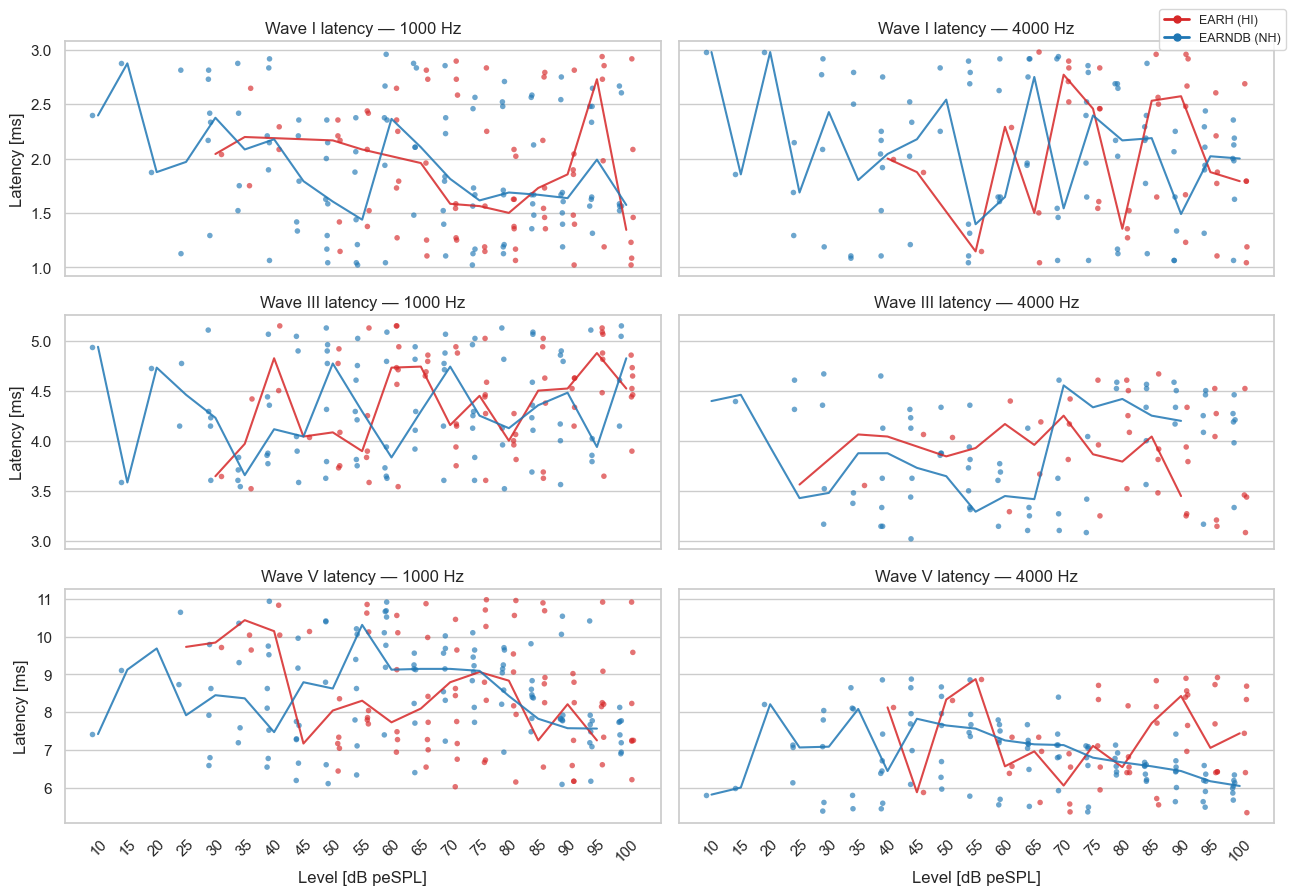

In [35]:
# -- Plot 1: Wave I / III / V latency overview (3 × 2) -----------------------
# FIX: median lines now use a level→x-position map so they align with the
#      stripplot columns regardless of which dataset covers which levels.
waves = ["I", "III", "V"]
fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex="col", sharey="row")

for r, wave in enumerate(waves):
    for c, freq in enumerate(FREQS):
        ax  = axes[r, c]
        col = f"wave_{wave}_latency_ms"
        sub = features[features.frequency_hz == freq].dropna(subset=[col])

        order = sorted(sub.level_db_pespl.unique())
        level_to_x = {lv: i for i, lv in enumerate(order)}

        sns.stripplot(data=sub, x="level_db_pespl", y=col,
                      hue="dataset", dodge=True, alpha=0.65, ax=ax, size=4,
                      palette=PALETTE, order=order, legend=False)

        # Median trend per dataset — x positions from the shared level_to_x map
        for ds, color in PALETTE.items():
            med = sub[sub.dataset == ds].groupby("level_db_pespl")[col].median()
            xs  = [level_to_x[lv] for lv in med.index]
            ax.plot(xs, med.values, color=color, lw=1.5, alpha=0.85, zorder=3)

        ax.set_title(f"Wave {wave} latency — {freq} Hz")
        ax.set_ylabel("Latency [ms]" if c == 0 else "")
        ax.set_xlabel("Level [dB peSPL]" if r == 2 else "")
        ax.tick_params(axis="x", rotation=45)

fig.legend(handles=LEGEND_H, loc="upper right", bbox_to_anchor=(1.0, 1.0),
           frameon=True, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_ROOT / "wave_peaks_overview.png", dpi=150, bbox_inches="tight")
plt.show()

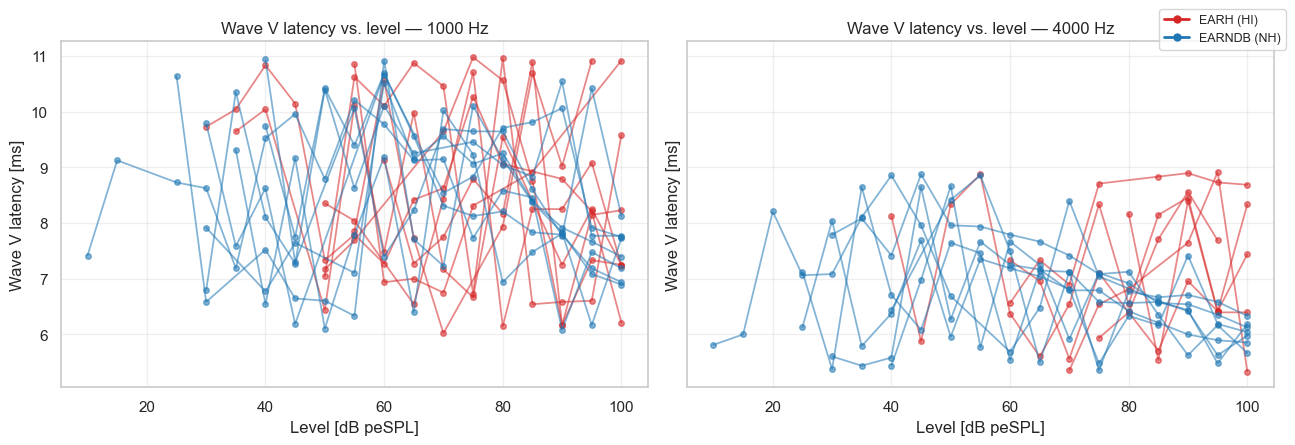

In [36]:
# -- Plot 2: Wave V latency level-functions (per subject) --------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, freq in zip(axes, FREQS):
    sub = features[features.frequency_hz == freq].dropna(subset=["wave_V_latency_ms"])
    for (ds, subj), grp in sub.groupby(["dataset", "subject"]):
        ax.plot(grp.level_db_pespl, grp.wave_V_latency_ms, "-o",
                alpha=0.55, ms=4, lw=1.3, color=PALETTE[ds])
    ax.set_title(f"Wave V latency vs. level — {freq} Hz")
    ax.set_xlabel("Level [dB peSPL]")
    ax.set_ylabel("Wave V latency [ms]")
    ax.grid(alpha=0.3)

fig.legend(handles=LEGEND_H, loc="upper right", bbox_to_anchor=(1.0, 1.0),
           frameon=True, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_ROOT / "latency_level_functions.png", dpi=150, bbox_inches="tight")
plt.show()

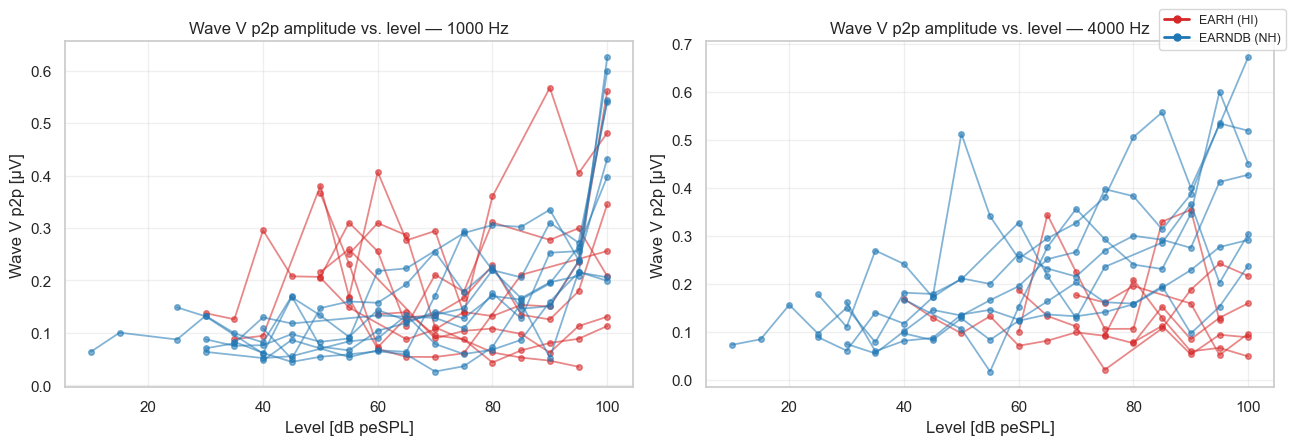

In [37]:
# -- Plot 3: Wave V amplitude level-functions (per subject) ------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, freq in zip(axes, FREQS):
    sub = features[features.frequency_hz == freq].dropna(subset=["wave_V_p2p_uv"])
    for (ds, subj), grp in sub.groupby(["dataset", "subject"]):
        ax.plot(grp.level_db_pespl, grp.wave_V_p2p_uv, "-o",
                alpha=0.55, ms=4, lw=1.3, color=PALETTE[ds])
    ax.set_title(f"Wave V p2p amplitude vs. level — {freq} Hz")
    ax.set_xlabel("Level [dB peSPL]")
    ax.set_ylabel("Wave V p2p [µV]")
    ax.grid(alpha=0.3)

fig.legend(handles=LEGEND_H, loc="upper right", bbox_to_anchor=(1.0, 1.0),
           frameon=True, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_ROOT / "amplitude_level_functions.png", dpi=150, bbox_inches="tight")
plt.show()

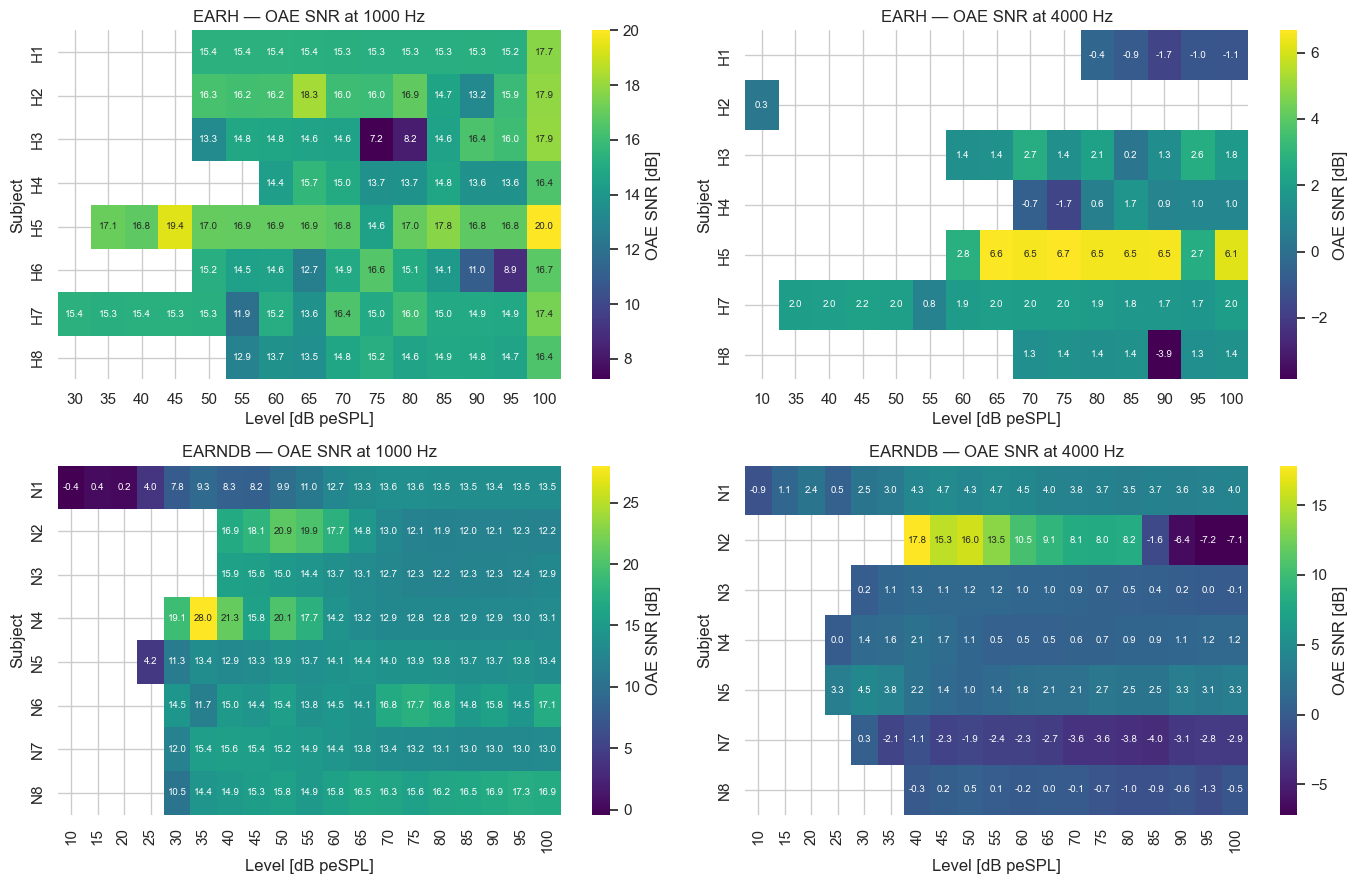

In [38]:
# -- Plot 4: OAE SNR heatmap (2 datasets × 2 frequencies) -------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_idx, ds in enumerate(["earh", "earndb"]):
    for col_idx, freq in enumerate(FREQS):
        ax  = axes[row_idx, col_idx]
        sub = features[(features.dataset == ds) & (features.frequency_hz == freq)
                       ].dropna(subset=["oae_snr_db"])
        if sub.empty:
            ax.set_visible(False)
            continue
        pivot = sub.pivot_table(index="subject", columns="level_db_pespl",
                                values="oae_snr_db", aggfunc="mean")
        sns.heatmap(pivot, cmap="viridis", annot=True, fmt=".1f", ax=ax,
                    cbar_kws={"label": "OAE SNR [dB]"},
                    annot_kws={"size": 7})
        ax.set_title(f"{ds.upper()} — OAE SNR at {freq} Hz")
        ax.set_xlabel("Level [dB peSPL]")
        ax.set_ylabel("Subject")

fig.tight_layout()
fig.savefig(OUT_ROOT / "oae_snr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

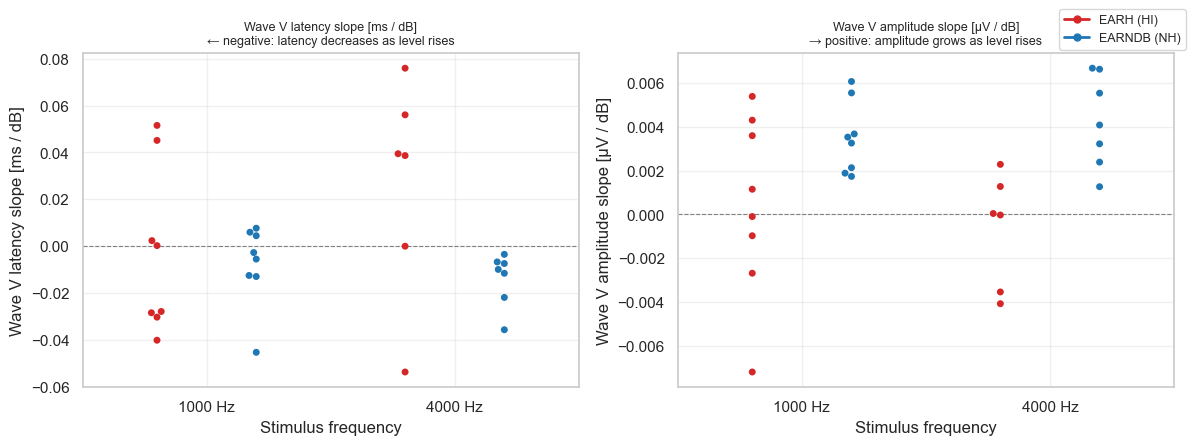

In [39]:
# -- Plot 5: Amplitude-level and latency-level slopes ------------------------
# FIX: frequency column converted to string labels before swarmplot so
#      matplotlib uses categorical ticks instead of numeric positions —
#      prevents jitter from creating phantom 500/3500 Hz tick marks.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

slope_pairs = [
    ("wave_V_latency_slope_ms_per_dB",   "Wave V latency slope [ms / dB]",
     "← negative: latency decreases as level rises"),
    ("wave_V_amplitude_slope_uv_per_dB", "Wave V amplitude slope [µV / dB]",
     "→ positive: amplitude grows as level rises"),
]
for ax, (col, ylabel, note) in zip(axes, slope_pairs):
    plot_data = slope_features.dropna(subset=[col]).copy()
    plot_data["freq_label"] = plot_data["frequency_hz"].astype(str) + " Hz"

    sns.swarmplot(data=plot_data, x="freq_label", y=col,
                  hue="dataset", dodge=True, ax=ax,
                  palette=PALETTE, legend=False,
                  order=["1000 Hz", "4000 Hz"])
    ax.axhline(0, color="0.5", lw=0.8, ls="--")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Stimulus frequency")
    ax.set_title(f"{ylabel}\n{note}", fontsize=9)
    ax.grid(alpha=0.3)

fig.legend(handles=LEGEND_H, loc="upper right", bbox_to_anchor=(1.0, 1.0),
           frameon=True, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_ROOT / "amplitude_level_slopes.png", dpi=150, bbox_inches="tight")
plt.show()

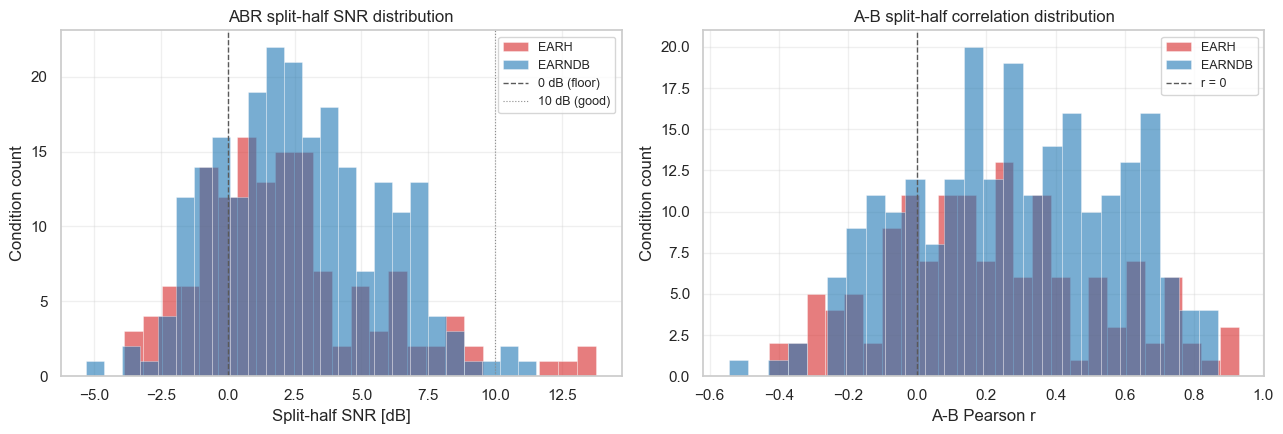

In [40]:
# -- Plot 6 (new): Split-half SNR + A-B correlation distributions ------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for ds in ["earh", "earndb"]:
    vals = features[features.dataset == ds]["abr_split_snr_db"].dropna()
    ax.hist(vals, bins=25, alpha=0.6, color=PALETTE[ds], label=ds.upper(),
            edgecolor="white", lw=0.4)
ax.axvline(0,  color="0.35", lw=1,   ls="--", label="0 dB (floor)")
ax.axvline(10, color="0.55", lw=0.8, ls=":",  label="10 dB (good)")
ax.set_xlabel("Split-half SNR [dB]")
ax.set_ylabel("Condition count")
ax.set_title("ABR split-half SNR distribution")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for ds in ["earh", "earndb"]:
    vals = features[features.dataset == ds]["abr_ab_corr"].dropna()
    ax.hist(vals, bins=25, alpha=0.6, color=PALETTE[ds], label=ds.upper(),
            edgecolor="white", lw=0.4)
ax.axvline(0, color="0.35", lw=1, ls="--", label="r = 0")
ax.set_xlabel("A-B Pearson r")
ax.set_ylabel("Condition count")
ax.set_title("A-B split-half correlation distribution")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_ROOT / "reliability_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

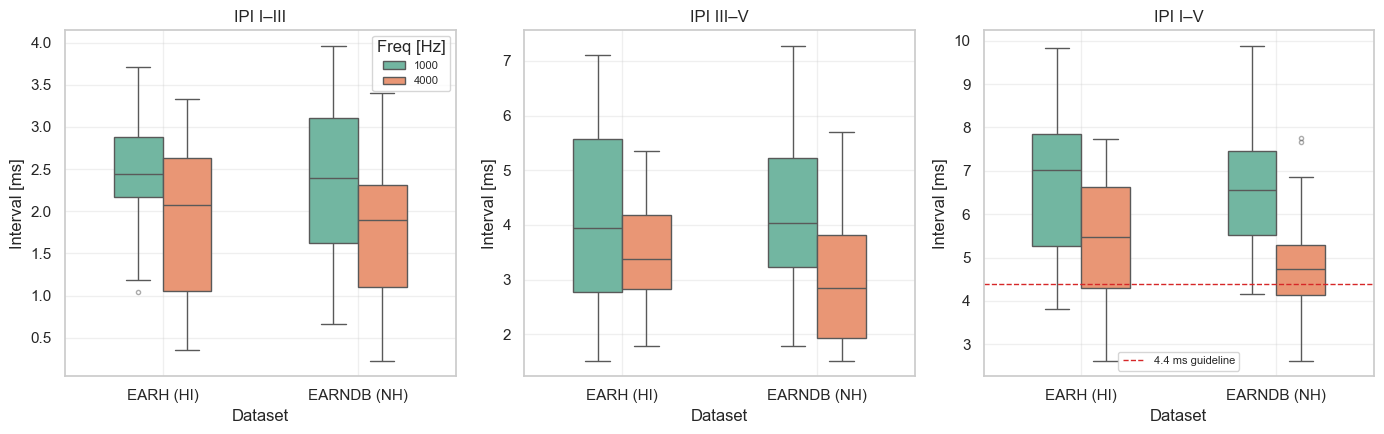

In [41]:
# -- Plot 7 (new): Inter-peak interval strip plots ---------------------------
# FIX: set_xticks() called before set_xticklabels() to suppress deprecation
#      warning from matplotlib about setting labels on a non-fixed locator.
ipi_pairs = [
    ("ipi_I_III_ms", "I–III"),
    ("ipi_III_V_ms", "III–V"),
    ("ipi_I_V_ms",   "I–V"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (col, name) in zip(axes, ipi_pairs):
    sub = features.dropna(subset=[col])
    sns.boxplot(data=sub, x="dataset", y=col, hue="frequency_hz",
                palette="Set2", width=0.5, ax=ax,
                order=["earh", "earndb"],
                legend=(ax == axes[0]),
                flierprops=dict(marker=".", alpha=0.5))
    ax.set_title(f"IPI {name}")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Interval [ms]")
    ax.set_xticks([0, 1])                                   # FIX
    ax.set_xticklabels(["EARH (HI)", "EARNDB (NH)"])
    ax.grid(alpha=0.3)
    if col == "ipi_I_V_ms":
        ax.axhline(4.4, color="tab:red", lw=1, ls="--", label="4.4 ms guideline")
        ax.legend(fontsize=8)

axes[0].legend(title="Freq [Hz]", fontsize=8)
fig.tight_layout()
fig.savefig(OUT_ROOT / "ipi_stripplots.png", dpi=150, bbox_inches="tight")
plt.show()

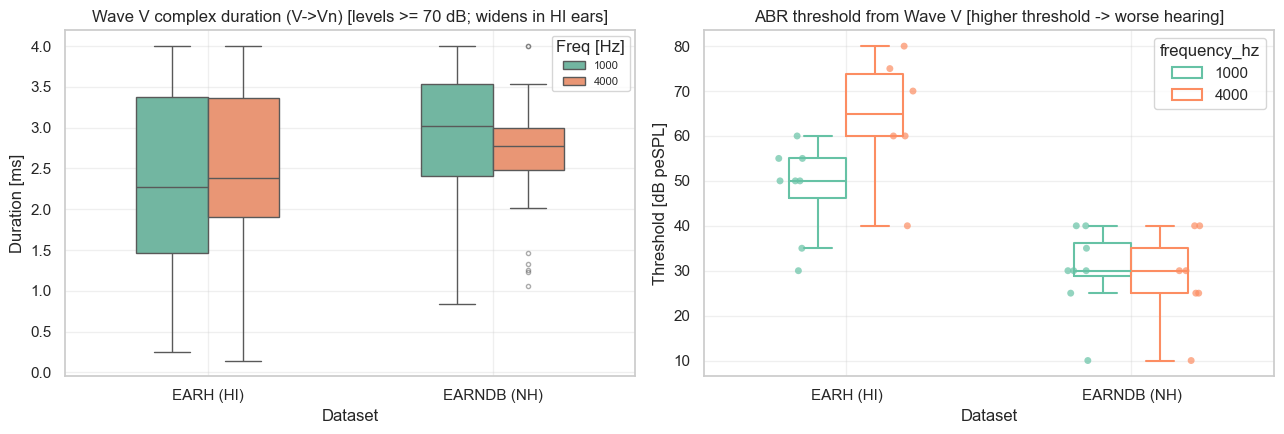

In [42]:
# -- Plot 8 (new): Wave V complex duration + ABR threshold-from-V ------------
# FIX: duration panel restricted to level >= 70 dB.
#      At low levels the trough detector frequently hits the 4 ms tail cap,
#      producing artefactually long durations that obscure the HI vs NH pattern.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
sub = features[
    (features.level_db_pespl >= 70)
].dropna(subset=["wave_V_complex_duration_ms"])
sns.boxplot(data=sub, x="dataset", y="wave_V_complex_duration_ms",
            hue="frequency_hz", palette="Set2", width=0.5, ax=ax,
            order=["earh", "earndb"],
            flierprops=dict(marker=".", alpha=0.5))
ax.set_title("Wave V complex duration (V->Vn) [levels >= 70 dB; widens in HI ears]")
ax.set_xlabel("Dataset")
ax.set_ylabel("Duration [ms]")
ax.set_xticks([0, 1])
ax.set_xticklabels(["EARH (HI)", "EARNDB (NH)"])
ax.legend(title="Freq [Hz]", fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
sf = slope_features.dropna(subset=["abr_threshold_db_v"])
sns.stripplot(data=sf, x="dataset", y="abr_threshold_db_v", hue="frequency_hz",
              dodge=True, jitter=True, alpha=0.7, ax=ax,
              order=["earh", "earndb"], palette="Set2", legend=False)
sns.boxplot(data=sf, x="dataset", y="abr_threshold_db_v", hue="frequency_hz",
            dodge=True, width=0.4, palette="Set2", ax=ax,
            order=["earh", "earndb"], fill=False,
            flierprops=dict(alpha=0))
ax.set_title("ABR threshold from Wave V [higher threshold -> worse hearing]")
ax.set_xlabel("Dataset")
ax.set_ylabel("Threshold [dB peSPL]")
ax.set_xticks([0, 1])
ax.set_xticklabels(["EARH (HI)", "EARNDB (NH)"])
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_ROOT / "wave_v_duration_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

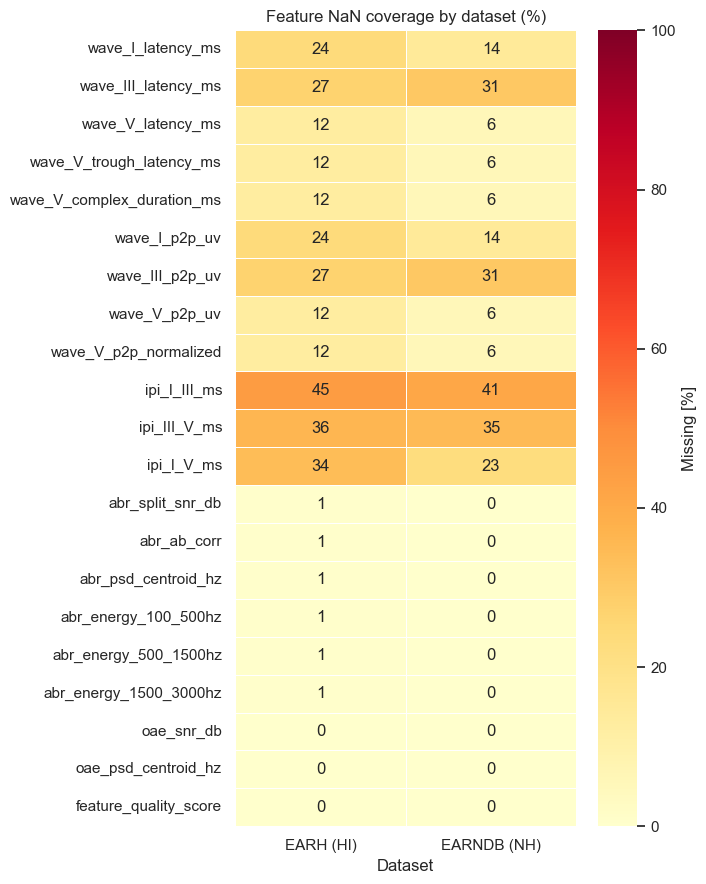


All plots saved:
  amplitude_level_functions.png
  amplitude_level_slopes.png
  ipi_stripplots.png
  latency_level_functions.png
  nan_coverage.png
  oae_snr_heatmap.png
  reliability_distributions.png
  wave_peaks_overview.png
  wave_v_duration_threshold.png


In [43]:
# -- Plot 9 (new): NaN coverage heatmap per feature × dataset ----------------
feat_cols_display = [
    "wave_I_latency_ms", "wave_III_latency_ms", "wave_V_latency_ms",
    "wave_V_trough_latency_ms", "wave_V_complex_duration_ms",
    "wave_I_p2p_uv", "wave_III_p2p_uv", "wave_V_p2p_uv",
    "wave_V_p2p_normalized",
    "ipi_I_III_ms", "ipi_III_V_ms", "ipi_I_V_ms",
    "abr_split_snr_db", "abr_ab_corr",
    "abr_psd_centroid_hz",
    "abr_energy_100_500hz", "abr_energy_500_1500hz", "abr_energy_1500_3000hz",
    "oae_snr_db", "oae_psd_centroid_hz",
    "feature_quality_score",
]

nan_df = pd.DataFrame({
    ds: features[features.dataset == ds][feat_cols_display].isna().mean() * 100
    for ds in ["earh", "earndb"]
})

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(nan_df, annot=True, fmt=".0f", cmap="YlOrRd", vmin=0, vmax=100,
            ax=ax, linewidths=0.4,
            cbar_kws={"label": "Missing [%]"})
ax.set_title("Feature NaN coverage by dataset (%)")
ax.set_xlabel("Dataset")
ax.set_ylabel("")
ax.set_xticklabels(["EARH (HI)", "EARNDB (NH)"], rotation=0)
fig.tight_layout()
fig.savefig(OUT_ROOT / "nan_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAll plots saved:")
for p in sorted(OUT_ROOT.glob("*.png")):
    print(f"  {p.name}")

## 11. Descriptive statistics

In [44]:
print("-- Per-condition features: descriptive statistics --")
display_cols = [
    "wave_I_latency_ms", "wave_III_latency_ms", "wave_V_latency_ms",
    "wave_V_p2p_uv", "wave_V_p2p_normalized",
    "wave_V_complex_duration_ms",
    "ipi_I_V_ms",
    "abr_psd_centroid_hz",
    "abr_split_snr_db", "abr_ab_corr",
    "oae_snr_db",
    "feature_quality_score",
]
print(features[display_cols].describe().round(3).to_string())

print()
print("-- Slope features --")
print(slope_features[
    ["wave_V_latency_slope_ms_per_dB",  "wave_V_latency_slope_r2",
     "wave_V_amplitude_slope_uv_per_dB","wave_V_amplitude_slope_r2",
     "n_levels_used", "abr_threshold_db_v"]
].describe().round(4).to_string())

-- Per-condition features: descriptive statistics --
       wave_I_latency_ms  wave_III_latency_ms  wave_V_latency_ms  wave_V_p2p_uv  wave_V_p2p_normalized  wave_V_complex_duration_ms  ipi_I_V_ms  abr_psd_centroid_hz  abr_split_snr_db  abr_ab_corr  oae_snr_db  feature_quality_score
count            305.000              263.000            341.000        341.000                341.000                     341.000     271.000              371.000           371.000      371.000     372.000                372.000
mean               1.972                4.178              7.800          0.184                  3.679                       2.557       5.923              401.228             2.514        0.252       8.948                  0.487
std                0.605                0.557              1.451          0.122                  1.620                       0.982       1.561              136.446             3.197        0.303       7.124                  0.194
min                1.021   

In [45]:
print("Output files written to:", OUT_ROOT.resolve())
for p in sorted(OUT_ROOT.iterdir()):
    print(f"  {p.name}")

Output files written to: C:\Users\apoor\Downloads\abr-oae-hearing-analysis-main\abr-oae-hearing-analysis-main\abr-oae-hearing-analysis-main\results\task3_features
  amplitude_level_functions.png
  amplitude_level_slopes.png
  features_per_condition.csv
  features_slope.csv
  ipi_stripplots.png
  latency_level_functions.png
  nan_coverage.png
  oae_snr_heatmap.png
  reliability_distributions.png
  wave_peaks_overview.png
  wave_v_duration_threshold.png


## 12. Summary of changes vs. the previous version

**Bug fixes — data pipeline**

1. **Loader no longer double-converts ABR units.** Wave V p2p amplitudes are now in the physiological 0.05–2 µV range. EARNDB band energies are no longer zero.
2. **`extract_abr_spectral` honors `qc_pass`.** All QC-failed conditions now have NaN for both temporal and spectral ABR features.
3. **`WAVEFORM_MAX_P2P_UV` rescaled to real µV units.** A single 10 µV threshold catches the EARH H2 / 4 kHz / 10 dB artifact without rejecting healthy averages.

**Upgrades — features**

1. `abr_split_snr_db` and `abr_ab_corr` replace the contaminated time-domain SNR.
2. `wave_V_trough_latency_ms` + `wave_V_complex_duration_ms` — V→Vn complex duration widens in HI ears.
3. `assert_units_are_uv()` runs before any feature is extracted.
4. `n_levels_used` per slope row + `MIN_LEVELS_FOR_SLOPE = 5` floor.
5. `abr_threshold_db_v` — lowest level with reliable Wave V.
6. `feature_quality_score` ∈ [0, 1] usable as `sample_weight=` in Tasks 4 / 5.

**Bug fixes — plots (§10)**

| Plot | Fix |
|---|---|
| 1 — Wave peaks overview | Median lines now use `level_to_x` map — previously used `range(len(med))` which shifted lines left when datasets had different level ranges |
| 5 — Slope swarmplots | `x="frequency_hz"` (numeric) replaced with `x="freq_label"` (string) — prevents swarmplot jitter from generating phantom 500/3500 Hz tick marks on the x-axis |
| 7 — IPI boxplots | `set_xticks([0, 1])` added before `set_xticklabels()` — suppresses matplotlib deprecation warning about setting labels on a non-fixed locator |
| 8 — Wave V complex duration | Filtered to level ≥ 70 dB — at low levels the 4 ms trough detection cap produces artefactually long durations that reverse the expected HI > NH direction |

**New plots added**

| File | Content |
|---|---|
| `reliability_distributions.png` | Split-half SNR and A-B correlation histograms per dataset |
| `ipi_stripplots.png` | I–III, III–V, I–V boxplots; 4.4 ms I–V clinical guideline |
| `wave_v_duration_threshold.png` | V→Vn complex duration (≥70 dB) and `abr_threshold_db_v` |
| `nan_coverage.png` | % missing per feature × dataset |